In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchtext
from torchtext.datasets import Multi30k
from torchtext.data import Field, BucketIterator

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import spacy
import numpy as np

import random
import math
import time

In [2]:
# we can set the random seeds for reproducability
SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [3]:
import torch.serialization
import numpy.core.multiarray

torch.serialization.add_safe_globals([
    numpy.core.multiarray._reconstruct
])


In [4]:
import torch
print(torch.__version__)


2.5.1+cpu


In [5]:
import stanza
# spacy_de = stanza.Pipeline('de')
# spacy_en = stanza.Pipeline('en')

spacy_en = stanza.Pipeline('en', processors='tokenize', tokenize_no_ssplit=True)
spacy_de = stanza.Pipeline('de', processors='tokenize', tokenize_no_ssplit=True)

2026-04-17 23:17:00 INFO: Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


2026-04-17 23:17:01 INFO: Loading these models for language: en (English):
| Processor | Package  |
------------------------
| tokenize  | combined |

2026-04-17 23:17:01 INFO: Using device: cpu
2026-04-17 23:17:01 INFO: Loading: tokenize
C:\Users\yathi\anaconda3\envs\pytorch\lib\site-packages\stanza\models\tokenization\trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`

2026-04-17 23:17:04 WARNING: Language de package default expects mwt, which has been added
2026-04-17 23:17:04 INFO: Loading these models for language: de (German):
| Processor | Package |
-----------------------
| tokenize  | gsd     |
| mwt       | gsd     |

2026-04-17 23:17:04 INFO: Using device: cpu
2026-04-17 23:17:04 INFO: Loading: tokenize
C:\Users\yathi\anaconda3\envs\pytorch\lib\site-packages\stanza\models\tokenization\trainer.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loa

In [6]:
# def tokenize_de(text):
#     """
#     Tokenizes German text from a string into a list of strings
#     """
#     return [tok.text for tok in spacy_de.tokenizer(text)]

# def tokenize_en(text):
#     """
#     Tokenizes English text from a string into a list of strings
#     """
#     return [tok.text for tok in spacy_en.tokenizer(text)]

# def tokenize_en(text):
#     doc = spacy_en(text)
#     return [word.text for sent in doc.sentences for word in sent.words]

# def tokenize_de(text):
#     doc = spacy_de(text)
#     return [word.text for sent in doc.sentences for word in sent.words]


# import re

# def tokenize_en(text):
#     return re.findall(r'\w+|\S', text.lower())

# def tokenize_de(text):
#     return re.findall(r'\w+|\S', text.lower())

def tokenize_en(text):
    doc = spacy_en(text)
    return [w.text for s in doc.sentences for w in s.words]

def tokenize_de(text):
    doc = spacy_de(text)
    return [w.text for s in doc.sentences for w in s.words]





In [7]:
SRC = Field(
    tokenize=tokenize_en, 
    init_token='<sos>', 
    eos_token='<eos>', 
    lower=True, 
    batch_first=True
)

TRG = Field(
    tokenize=tokenize_de, 
    init_token='<sos>', 
    eos_token='<eos>', 
    lower=True, 
    batch_first=True
)

In [8]:
open('.data/multi30k/hello.txt').read()

'Hello World !!!'

In [10]:
# train_data, valid_data, test_data = Multi30k.splits(
#     exts=('.en', '.de'), 
#     fields=(SRC, TRG)
# )

train_data, valid_data, test_data = Multi30k.splits(
    exts=('.en', '.de'),
    fields=(SRC, TRG),
    root='.data/'
)


In [11]:
# SRC.build_vocab(train_data, min_freq=2)
# TRG.build_vocab(train_data, min_freq=2)
# [26]
SRC.build_vocab(train_data, min_freq=2)
TRG.build_vocab(train_data, min_freq=2)


In [12]:
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# [27] – device selection (CPU or GPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)


Using device: cpu


In [13]:
assert device.__str__() == 'cpu'

In [14]:
# BATCH_SIZE = 128

# train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
#     (train_data, valid_data, test_data), 
#      batch_size=BATCH_SIZE,
#      device=device
# )

# [29] – iterators
BATCH_SIZE = 128

train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size=BATCH_SIZE,
    device=device
)


In [15]:
# class Encoder(nn.Module):
#     def __init__(self,
#                  input_dim,
#                  hid_dim,
#                  n_layers,
#                  n_heads,
#                  pf_dim,
#                  dropout,
#                  device,
#                  max_length=100):
#         super().__init__()
#         self.device = device
#         self.tok_embedding = nn.Embedding(input_dim, hid_dim)
#         self.pos_embedding = nn.Embedding(max_length, hid_dim)
#         self.layers = nn.ModuleList(
#             [EncoderLayer(
#                 hid_dim,
#                 n_heads,
#                 pf_dim,
#                 dropout,
#                 device
#             ) for _ in range(n_layers)])
#         self.dropout = nn.Dropout(dropout)
#         self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)
        
#     def forward(self, src, src_mask):
#         batch_size = src.shape[0]
#         src_len = src.shape[1]
#         pos = torch.arange(
#             0, src_len
#         ).unsqueeze(0).repeat(
#             batch_size, 1
#         ).to(self.device)
#         src = self.dropout(
#             (self.tok_embedding(src) * self.scale) +
#             self.pos_embedding(pos)
#         )
#         for layer in self.layers:
#             src = layer(src, src_mask)
#         return src

In [16]:
# [30] – Encoder
class Encoder(nn.Module):
    def __init__(self,
                 input_dim,
                 hid_dim,
                 n_layers,
                 n_heads,
                 pf_dim,
                 dropout,
                 device,
                 max_length=100):
        super().__init__()

        self.device = device

        self.tok_embedding = nn.Embedding(input_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)

        self.layers = nn.ModuleList(
            [EncoderLayer(hid_dim,
                          n_heads,
                          pf_dim,
                          dropout,
                          device)
             for _ in range(n_layers)]
        )

        self.dropout = nn.Dropout(dropout)
        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, src, src_mask):
        batch_size = src.shape[0]
        src_len = src.shape[1]

        pos = torch.arange(0, src_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)

        src = self.dropout(
            (self.tok_embedding(src) * self.scale) +
            self.pos_embedding(pos)
        )

        for layer in self.layers:
            src = layer(src, src_mask)

        return src


In [17]:
# [31] – EncoderLayer
class EncoderLayer(nn.Module):
    def __init__(self,
                 hid_dim,
                 n_heads,
                 pf_dim,
                 dropout,
                 device):
        super().__init__()

        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)
        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src, src_mask):
        _src, _ = self.self_attention(src, src, src, src_mask)
        src = self.self_attn_layer_norm(src + self.dropout(_src))

        _src = self.positionwise_feedforward(src)
        src = self.ff_layer_norm(src + self.dropout(_src))

        return src


In [18]:
# [32] – MultiHeadAttentionLayer
class MultiHeadAttentionLayer(nn.Module):
    def __init__(self, hid_dim, n_heads, dropout, device):
        super().__init__()

        assert hid_dim % n_heads == 0

        self.hid_dim = hid_dim
        self.n_heads = n_heads
        self.head_dim = hid_dim // n_heads

        self.fc_q = nn.Linear(hid_dim, hid_dim)
        self.fc_k = nn.Linear(hid_dim, hid_dim)
        self.fc_v = nn.Linear(hid_dim, hid_dim)

        self.fc_o = nn.Linear(hid_dim, hid_dim)

        self.dropout = nn.Dropout(dropout)

        self.scale = torch.sqrt(torch.FloatTensor([self.head_dim])).to(device)

    def forward(self, query, key, value, mask=None):
        batch_size = query.shape[0]

        Q = self.fc_q(query)
        K = self.fc_k(key)
        V = self.fc_v(value)

        Q = Q.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        K = K.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)
        V = V.view(batch_size, -1, self.n_heads, self.head_dim).permute(0, 2, 1, 3)

        energy = torch.matmul(Q, K.permute(0, 1, 3, 2)) / self.scale

        if mask is not None:
            energy = energy.masked_fill(mask == 0, -1e10)

        attention = torch.softmax(energy, dim=-1)

        x = torch.matmul(self.dropout(attention), V)

        x = x.permute(0, 2, 1, 3).contiguous()
        x = x.view(batch_size, -1, self.hid_dim)

        x = self.fc_o(x)

        return x, attention


In [19]:
# [33] – PositionwiseFeedforwardLayer
class PositionwiseFeedforwardLayer(nn.Module):
    def __init__(self, hid_dim, pf_dim, dropout):
        super().__init__()

        self.fc_1 = nn.Linear(hid_dim, pf_dim)
        self.fc_2 = nn.Linear(pf_dim, hid_dim)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.dropout(torch.relu(self.fc_1(x)))
        x = self.fc_2(x)
        return x


In [20]:
# [34] – Decoder
class Decoder(nn.Module):
    def __init__(self,
                 output_dim,
                 hid_dim,
                 n_layers,
                 n_heads,
                 pf_dim,
                 dropout,
                 device,
                 max_length=100):
        super().__init__()

        self.device = device

        self.tok_embedding = nn.Embedding(output_dim, hid_dim)
        self.pos_embedding = nn.Embedding(max_length, hid_dim)

        self.layers = nn.ModuleList(
            [DecoderLayer(hid_dim,
                          n_heads,
                          pf_dim,
                          dropout,
                          device)
             for _ in range(n_layers)]
        )

        self.fc_out = nn.Linear(hid_dim, output_dim)

        self.dropout = nn.Dropout(dropout)

        self.scale = torch.sqrt(torch.FloatTensor([hid_dim])).to(device)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        batch_size = trg.shape[0]
        trg_len = trg.shape[1]

        pos = torch.arange(0, trg_len).unsqueeze(0).repeat(batch_size, 1).to(self.device)

        trg = self.dropout(
            (self.tok_embedding(trg) * self.scale) +
            self.pos_embedding(pos)
        )

        for layer in self.layers:
            trg, attention = layer(trg, enc_src, trg_mask, src_mask)

        output = self.fc_out(trg)

        return output, attention


In [21]:
# [35] – DecoderLayer
class DecoderLayer(nn.Module):
    def __init__(self,
                 hid_dim,
                 n_heads,
                 pf_dim,
                 dropout,
                 device):
        super().__init__()

        self.self_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.enc_attn_layer_norm = nn.LayerNorm(hid_dim)
        self.ff_layer_norm = nn.LayerNorm(hid_dim)

        self.self_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.encoder_attention = MultiHeadAttentionLayer(hid_dim, n_heads, dropout, device)
        self.positionwise_feedforward = PositionwiseFeedforwardLayer(hid_dim, pf_dim, dropout)

        self.dropout = nn.Dropout(dropout)

    def forward(self, trg, enc_src, trg_mask, src_mask):
        _trg, _ = self.self_attention(trg, trg, trg, trg_mask)
        trg = self.self_attn_layer_norm(trg + self.dropout(_trg))

        _trg, attention = self.encoder_attention(trg, enc_src, enc_src, src_mask)
        trg = self.enc_attn_layer_norm(trg + self.dropout(_trg))

        _trg = self.positionwise_feedforward(trg)
        trg = self.ff_layer_norm(trg + self.dropout(_trg))

        return trg, attention


In [22]:
# [36] – Seq2Seq
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, src_pad_idx, trg_pad_idx, device):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.src_pad_idx = src_pad_idx
        self.trg_pad_idx = trg_pad_idx
        self.device = device

    def make_src_mask(self, src):
        src_mask = (src != self.src_pad_idx).unsqueeze(1).unsqueeze(2)
        return src_mask

    def make_trg_mask(self, trg):
        trg_pad_mask = (trg != self.trg_pad_idx).unsqueeze(1).unsqueeze(2)
        trg_len = trg.shape[1]
        trg_sub_mask = torch.tril(torch.ones((trg_len, trg_len), device=self.device)).bool()
        trg_mask = trg_pad_mask & trg_sub_mask
        return trg_mask

    def forward(self, src, trg):
        src_mask = self.make_src_mask(src)
        trg_mask = self.make_trg_mask(trg)

        enc_src = self.encoder(src, src_mask)

        output, attention = self.decoder(trg, enc_src, trg_mask, src_mask)

        return output, attention


In [23]:
# [37] – hyperparameters and model
INPUT_DIM = len(SRC.vocab)
OUTPUT_DIM = len(TRG.vocab)
HID_DIM = 256
ENC_LAYERS = 3
DEC_LAYERS = 3
ENC_HEADS = 8
DEC_HEADS = 8
ENC_PF_DIM = 512
DEC_PF_DIM = 512
ENC_DROPOUT = 0.1
DEC_DROPOUT = 0.1

enc = Encoder(
    INPUT_DIM,
    HID_DIM,
    ENC_LAYERS,
    ENC_HEADS,
    ENC_PF_DIM,
    ENC_DROPOUT,
    device
)

dec = Decoder(
    OUTPUT_DIM,
    HID_DIM,
    DEC_LAYERS,
    DEC_HEADS,
    DEC_PF_DIM,
    DEC_DROPOUT,
    device
)


In [24]:
# [38] – Seq2Seq model
SRC_PAD_IDX = SRC.vocab.stoi[SRC.pad_token]
TRG_PAD_IDX = TRG.vocab.stoi[TRG.pad_token]

model = Seq2Seq(enc, dec, SRC_PAD_IDX, TRG_PAD_IDX, device).to(device)


In [25]:
# [39] – parameter count
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')


The model has 9,553,085 trainable parameters


In [26]:
# [40] – weight init
def initialize_weights(m):
    if hasattr(m, 'weight') and m.weight.dim() > 1:
        nn.init.xavier_uniform_(m.weight.data)

model.apply(initialize_weights);


In [27]:
# [41] – optimizer
LEARNING_RATE = 0.0005
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)


In [28]:
# [42] – loss
criterion = nn.CrossEntropyLoss(ignore_index=TRG_PAD_IDX)


In [29]:
# [43] – train loop
def train(model, iterator, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    for i, batch in enumerate(iterator):
        src = batch.src
        trg = batch.trg

        optimizer.zero_grad()

        output, _ = model(src, trg[:, :-1])

        output_dim = output.shape[-1]

        output = output.contiguous().view(-1, output_dim)
        trg = trg[:, 1:].contiguous().view(-1)

        loss = criterion(output, trg)

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), clip)

        optimizer.step()

        epoch_loss += loss.item()

    return epoch_loss / len(iterator)


In [30]:
# [44] – eval loop
def evaluate(model, iterator, criterion):
    model.eval()
    epoch_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(iterator):
            src = batch.src
            trg = batch.trg

            output, _ = model(src, trg[:, :-1])

            output_dim = output.shape[-1]

            output = output.contiguous().view(-1, output_dim)
            trg = trg[:, 1:].contiguous().view(-1)

            loss = criterion(output, trg)

            epoch_loss += loss.item()

    return epoch_loss / len(iterator)


In [31]:
# [45] – epoch time
def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs


In [32]:
# [46] – training loop
N_EPOCHS = 10
CLIP = 1

best_valid_loss = float('inf')

for epoch in range(N_EPOCHS):
    start_time = time.time()

    train_loss = train(model, train_iterator, optimizer, criterion, CLIP)
    valid_loss = evaluate(model, valid_iterator, criterion)

    end_time = time.time()

    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), 'en2de-model.pt')

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train PPL: {math.exp(train_loss):7.3f}')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. PPL: {math.exp(valid_loss):7.3f}')


Epoch: 01 | Time: 2m 11s
	Train Loss: 4.342 | Train PPL:  76.832
	 Val. Loss: 3.059 |  Val. PPL:  21.316
Epoch: 02 | Time: 2m 15s
	Train Loss: 2.803 | Train PPL:  16.487
	 Val. Loss: 2.280 |  Val. PPL:   9.777
Epoch: 03 | Time: 2m 19s
	Train Loss: 2.196 | Train PPL:   8.986
	 Val. Loss: 1.923 |  Val. PPL:   6.838
Epoch: 04 | Time: 2m 19s
	Train Loss: 1.825 | Train PPL:   6.206
	 Val. Loss: 1.743 |  Val. PPL:   5.712
Epoch: 05 | Time: 2m 16s
	Train Loss: 1.566 | Train PPL:   4.788
	 Val. Loss: 1.616 |  Val. PPL:   5.033
Epoch: 06 | Time: 2m 18s
	Train Loss: 1.362 | Train PPL:   3.904
	 Val. Loss: 1.548 |  Val. PPL:   4.701
Epoch: 07 | Time: 2m 18s
	Train Loss: 1.201 | Train PPL:   3.325
	 Val. Loss: 1.494 |  Val. PPL:   4.455
Epoch: 08 | Time: 3m 28s
	Train Loss: 1.068 | Train PPL:   2.910
	 Val. Loss: 1.509 |  Val. PPL:   4.522
Epoch: 09 | Time: 2m 17s
	Train Loss: 0.952 | Train PPL:   2.591
	 Val. Loss: 1.473 |  Val. PPL:   4.361
Epoch: 10 | Time: 2m 16s
	Train Loss: 0.858 | Train PPL

In [50]:
# [47] – load best model + test
model.load_state_dict(torch.load('en2de-model.pt', map_location=device))
test_loss = evaluate(model, test_iterator, criterion)
print(f'| Test Loss: {test_loss:.3f} | Test PPL: {math.exp(test_loss):7.3f} |')


C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3945773423.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('en2de-model.pt', map_locat

| Test Loss: 1.471 | Test PPL:   4.356 |


In [51]:
# [48] – translate_sentence (modified to use your tokenizer, not spaCy model)
def translate_sentence(sentence, src_field, trg_field, model, device, max_len=50):
    model.eval()

    # use your existing tokenize_en if sentence is a string
    if isinstance(sentence, str):
        tokens = tokenize_en(sentence)
    else:
        tokens = [token.lower() for token in sentence]

    tokens = [src_field.init_token] + tokens + [src_field.eos_token]

    src_indexes = [src_field.vocab.stoi[token] for token in tokens]

    src_tensor = torch.LongTensor(src_indexes).unsqueeze(0).to(device)

    src_mask = model.make_src_mask(src_tensor)

    with torch.no_grad():
        enc_src = model.encoder(src_tensor, src_mask)

    trg_indexes = [trg_field.vocab.stoi[trg_field.init_token]]

    for i in range(max_len):
        trg_tensor = torch.LongTensor(trg_indexes).unsqueeze(0).to(device)

        trg_mask = model.make_trg_mask(trg_tensor)

        with torch.no_grad():
            output, attention = model.decoder(trg_tensor, enc_src, trg_mask, src_mask)

        pred_token = output.argmax(2)[:, -1].item()

        trg_indexes.append(pred_token)

        if pred_token == trg_field.vocab.stoi[trg_field.eos_token]:
            break

    trg_tokens = [trg_field.vocab.itos[i] for i in trg_indexes]

    return trg_tokens[1:], attention


In [52]:
# [49] – display_attention (unchanged)
def display_attention(sentence, translation, attention, n_heads=8, n_rows=4, n_cols=2):
    assert n_rows * n_cols == n_heads

    fig = plt.figure(figsize=(15, 25))

    for i in range(n_heads):
        ax = fig.add_subplot(n_rows, n_cols, i+1)

        _attention = attention.squeeze(0)[i].cpu().detach().numpy()

        cax = ax.matshow(_attention, cmap='bone')

        ax.tick_params(labelsize=12)
        ax.set_xticklabels([''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
                           rotation=45)
        ax.set_yticklabels([''] + translation)

        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()
    plt.close()


In [53]:
# [50] – BLEU
from torchtext.data.metrics import bleu_score  # works with torchtext 0.7.0

def calculate_bleu(data, src_field, trg_field, model, device, max_len=50):
    trgs = []
    pred_trgs = []

    for datum in data:
        src = vars(datum)['src']
        trg = vars(datum)['trg']

        pred_trg, _ = translate_sentence(src, src_field, trg_field, model, device, max_len)

        # cut off <eos>
        pred_trg = pred_trg[:-1]

        pred_trgs.append(pred_trg)
        trgs.append([trg])

    return bleu_score(pred_trgs, trgs)





In [56]:
# [51] – compute BLEU
# bleu = calculate_bleu(test_data, SRC, TRG, model, device)
# print(f'BLEU score = {bleu*100:.2f}')
src = "A man is playing guitar."
translation, attention = translate_sentence(src, SRC, TRG, model, device)
print("predicted trg =", translation)



predicted trg = ['ein', '<unk>', 'spielt', 'gitarre', '.', '<eos>']


In [57]:
translation, attention = translate_sentence(src, SRC, TRG, model, device)

print(f'predicted trg = {translation}')

example_idx = 8
src = vars(train_data.examples[example_idx])['src']


predicted trg = ['ein', '<unk>', 'spielt', 'gitarre', '.', '<eos>']


C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_

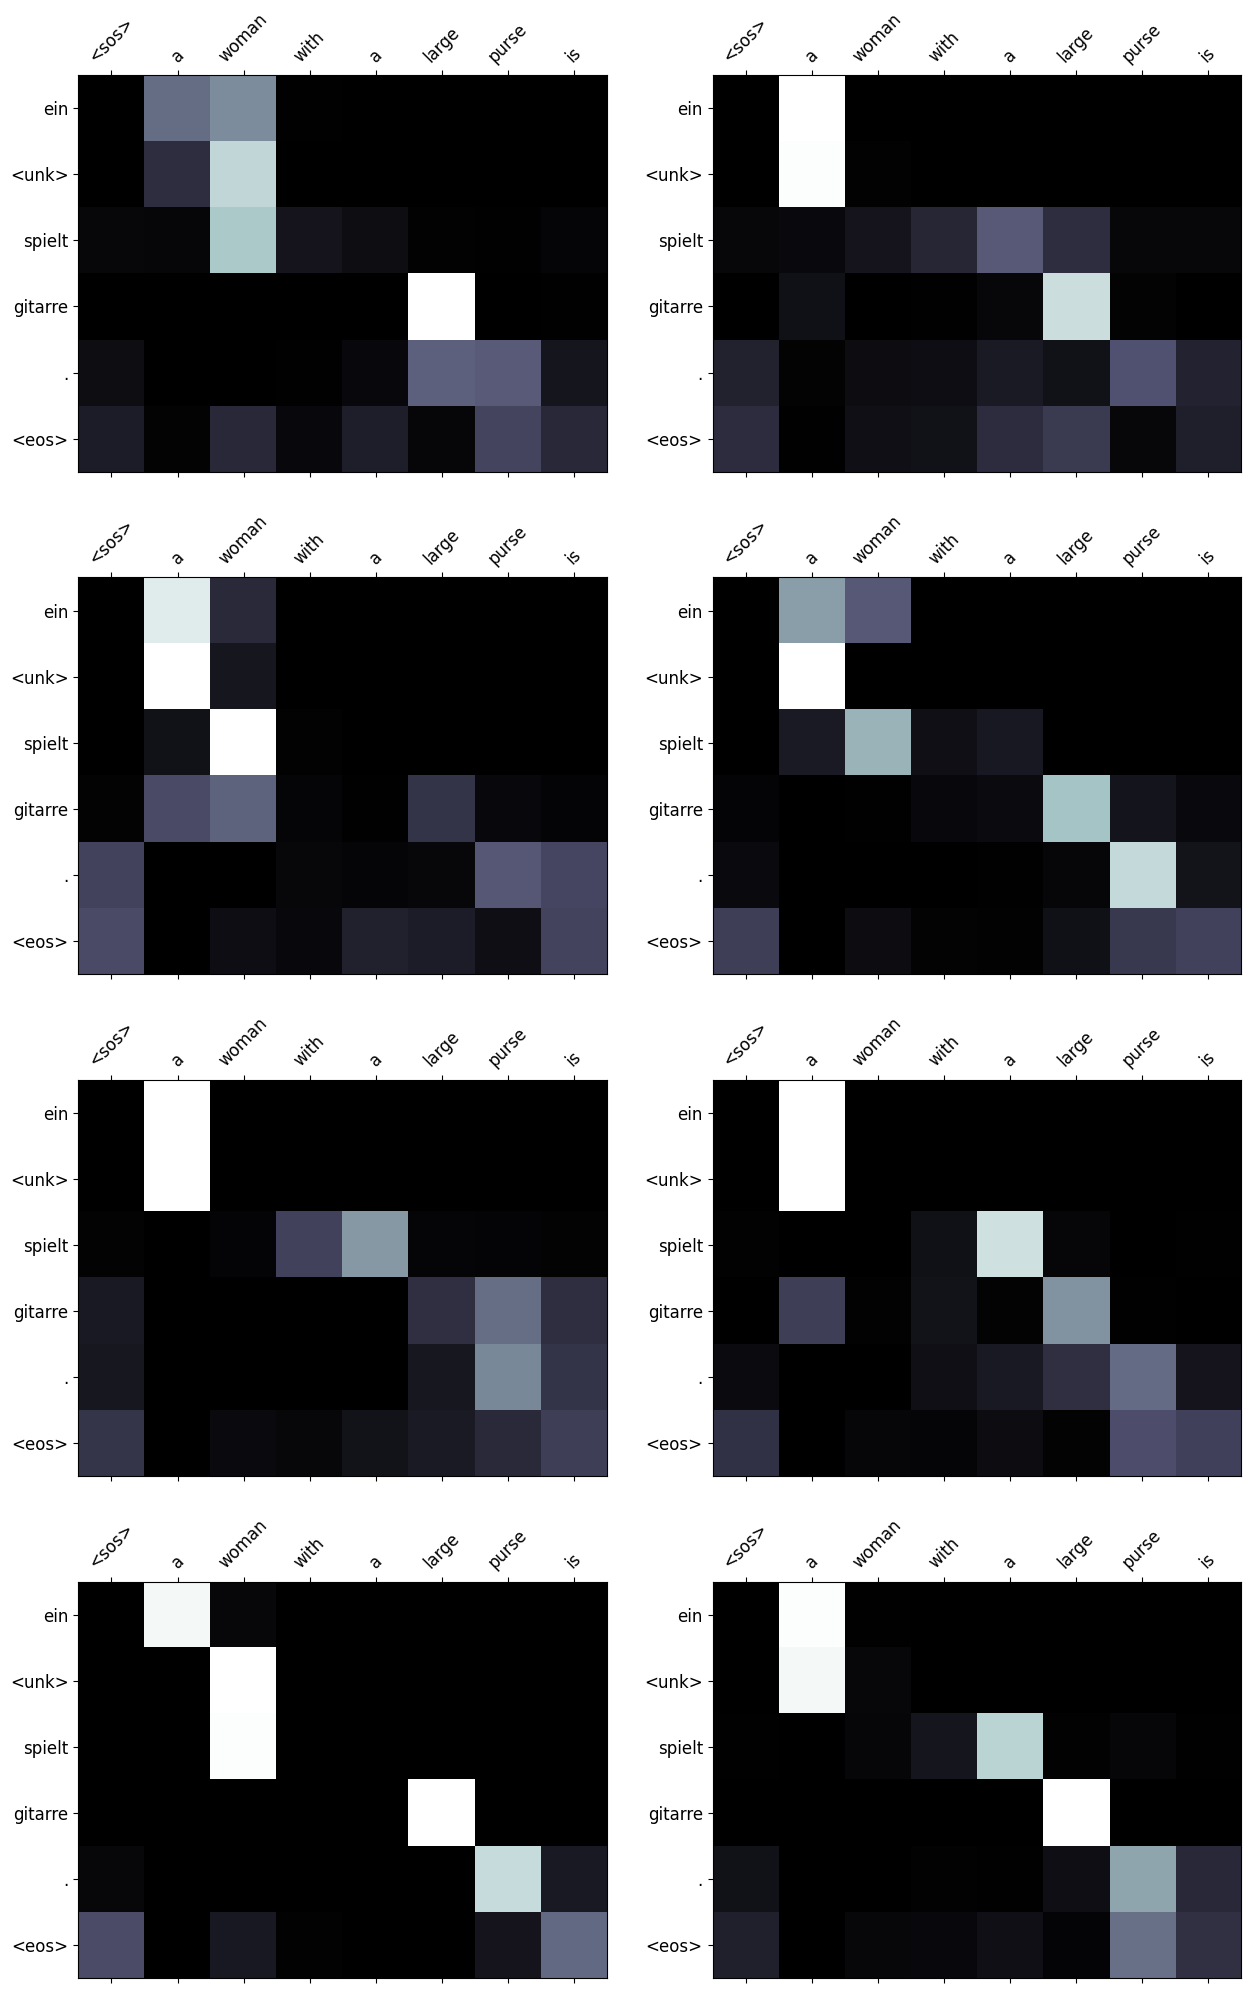

In [58]:
display_attention(src, translation, attention)

In [59]:
example_idx = 6

src = vars(valid_data.examples[example_idx])['src']
trg = vars(valid_data.examples[example_idx])['trg']

print(f'src = {src}')
print(f'trg = {trg}')

src = ['a', 'brown', 'dog', 'is', 'running', 'after', 'the', 'black', 'dog', '.']
trg = ['ein', 'brauner', 'hund', 'rennt', 'dem', 'schwarzen', 'hund', 'hinterher', '.']


In [60]:
translation, attention = translate_sentence(src, SRC, TRG, model, device)

print(f'predicted trg = {translation}')

predicted trg = ['ein', 'brauner', 'hund', 'rennt', 'nach', 'dem', 'schwarzen', 'hund', '.', '<eos>']


C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([''] + translation)
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([''] + ['<sos>'] + [t.lower() for t in sentence] + ['<eos>'],
C:\Users\yathi\AppData\Local\Temp\ipykernel_16012\3585936188.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_

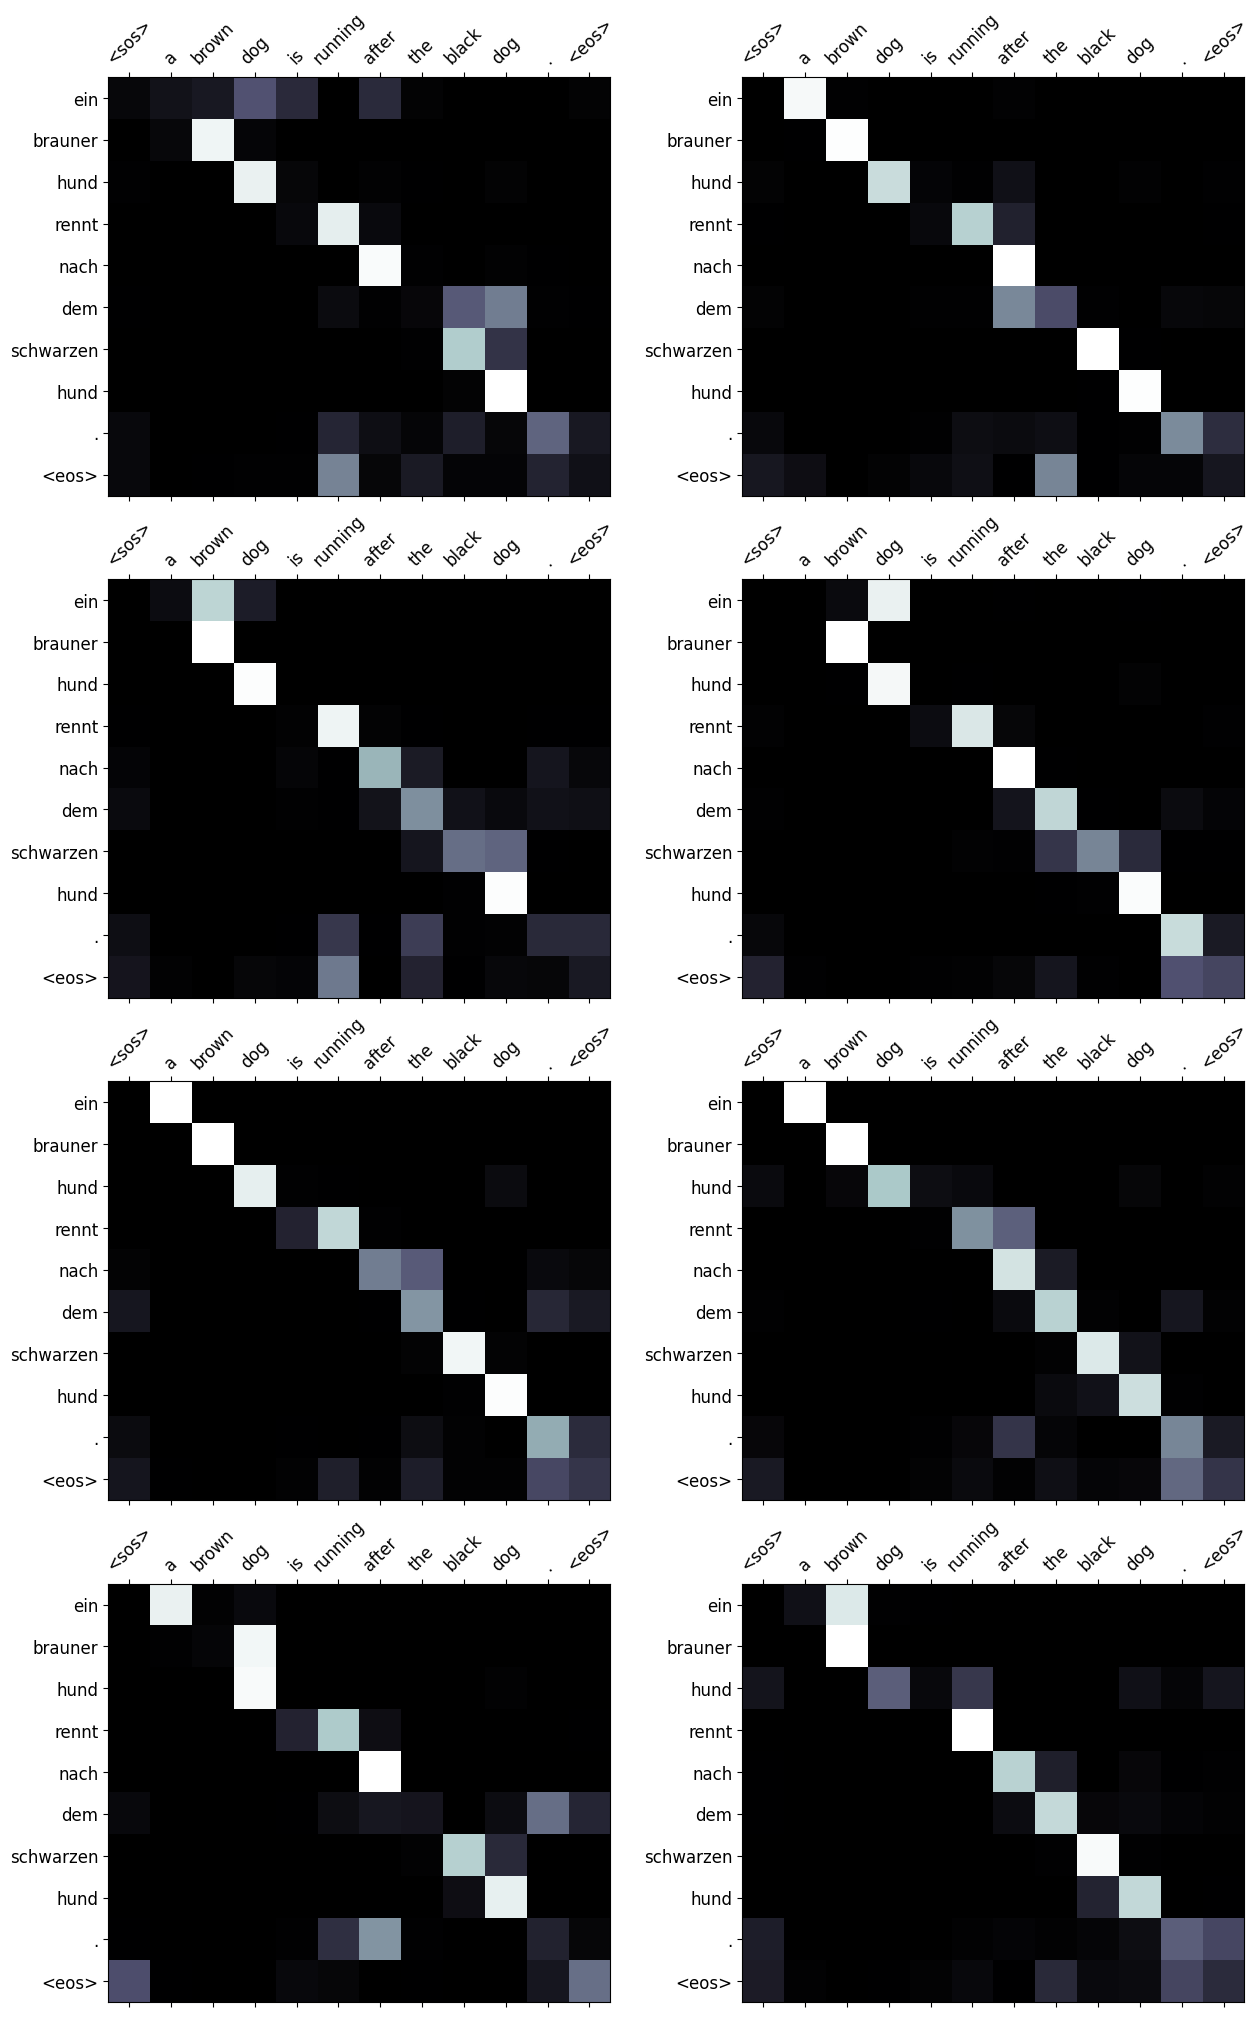

In [61]:
display_attention(src, translation, attention)

Finally, we'll look at an example from the test data.

In [ ]:
example_idx = 10

src = vars(test_data.examples[example_idx])['src']
trg = vars(test_data.examples[example_idx])['trg']

print(f'src = {src}')
print(f'trg = {trg}')

src = ['a', 'mother', 'and', 'her', 'young', 'song', 'enjoying', 'a', 'beautiful', 'day', 'outside', '.']
trg = ['eine', 'mutter', 'und', 'ihr', 'kleiner', 'sohn', 'genießen', 'einen', 'schönen', 'tag', 'im', 'freien', '.']


A decent translation with *young* being omitted.

In [ ]:
translation, attention = translate_sentence(src, SRC, TRG, model, device)

print(f'predicted trg = {translation}')

predicted trg = ['eine', 'mutter', 'und', 'ihre', 'kleine', 'jungen', 'genießen', 'ein', '<unk>', 'im', 'freien', '.', '<eos>']


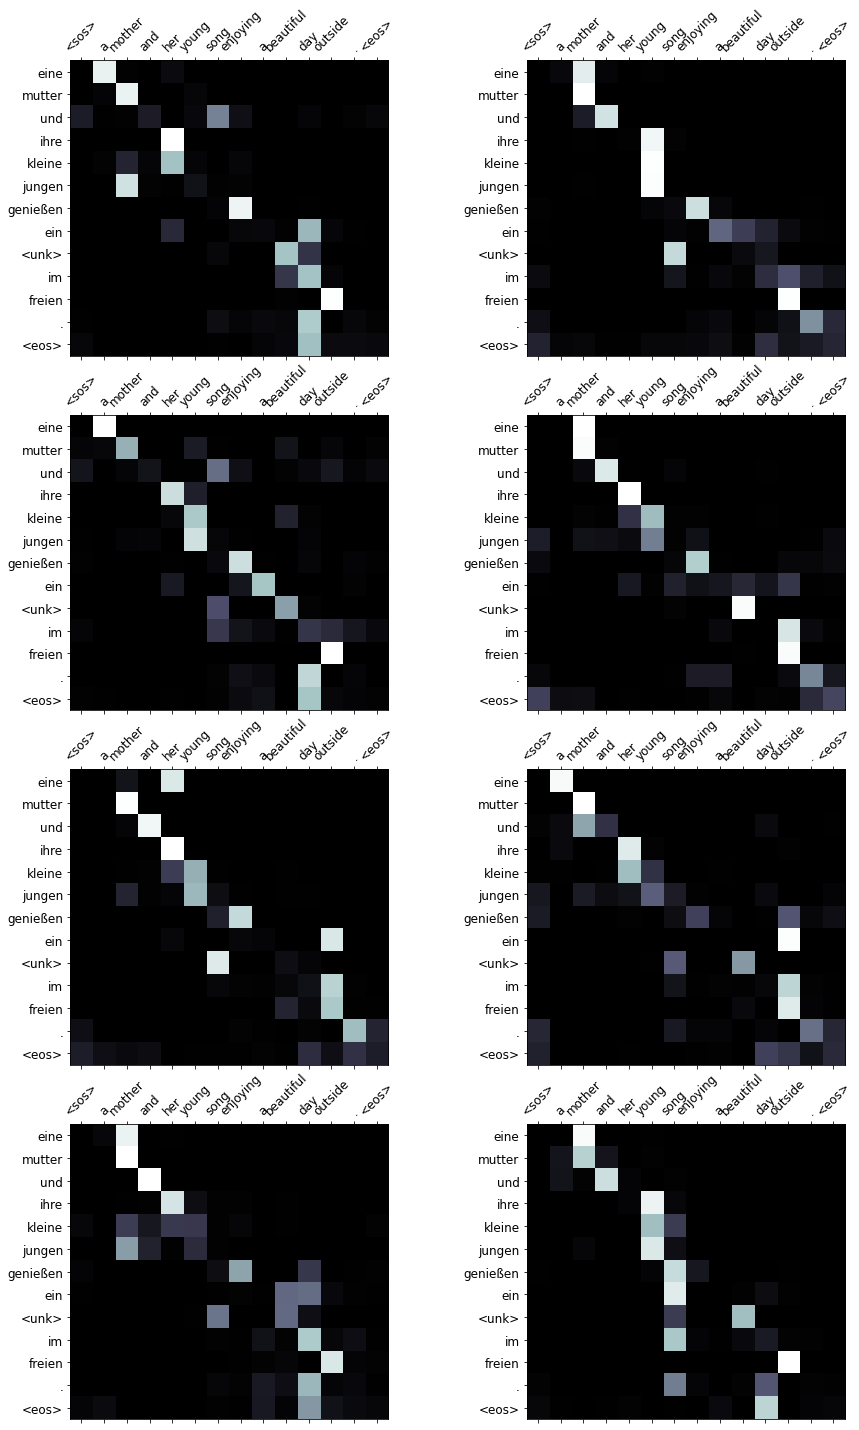

In [ ]:
display_attention(src, translation, attention)

In [69]:
from torchtext.data.metrics import bleu_score  # works in torchtext-0.7.0

def calculate_bleu(data, src_field, trg_field, model, device, max_len=50):
    trgs = []
    pred_trgs = []
    
    for datum in data:
        src = vars(datum)['src']
        trg = vars(datum)['trg']
        pred_trg, _ = translate_sentence(src, src_field, trg_field, model, device, max_len)
        
        #cut off <eos> token
        pred_trg = pred_trg[:-1]
        
        pred_trgs.append(pred_trg)
        trgs.append([trg])
        ret_blue_score = bleu_score(pred_trgs, trgs)

    print("BLUE SCORE: ", ret_blue_score)
    return ret_blue_score

In [ ]:
bleu_value = calculate_bleu(test_data, SRC, TRG, model, device)


VALUES:  [['ein', 'mann', 'mit', 'einem', 'orangefarbenen', 'hut', 'starrt', 'auf', 'etwas', '.']]  |  [[['ein', 'mann', 'mit', 'einem', 'orangefarbenen', 'hut', ',', 'der', 'etwas', 'anstarrt', '.']]]
BLUE SCORE:  0.5026587324050619
VALUES:  [['ein', 'mann', 'mit', 'einem', 'orangefarbenen', 'hut', 'starrt', 'auf', 'etwas', '.'], ['ein', '<unk>', '-', 'terrier', 'rennt', 'auf', 'grünem', 'gras', 'vor', 'einem', 'weißen', 'zaun', '.']]  |  [[['ein', 'mann', 'mit', 'einem', 'orangefarbenen', 'hut', ',', 'der', 'etwas', 'anstarrt', '.']], [['ein', 'boston', 'terrier', 'läuft', 'über', 'saftig', '-', 'grünes', 'gras', 'vor', 'einem', 'weißen', 'zaun', '.']]]
BLUE SCORE:  0.4383998536892718
VALUES:  [['ein', 'mann', 'mit', 'einem', 'orangefarbenen', 'hut', 'starrt', 'auf', 'etwas', '.'], ['ein', '<unk>', '-', 'terrier', 'rennt', 'auf', 'grünem', 'gras', 'vor', 'einem', 'weißen', 'zaun', '.'], ['ein', 'mädchen', 'in', 'karateanzügen', 'führt', 'einen', 'stock', 'vor', '.']]  |  [[['ein', 'm

In [67]:
bleu = calculate_bleu(test_data, SRC, TRG, model, device)
print(f'BLEU score = {bleu*100:.2f}')

# compute BLEU
bleu = calculate_bleu(test_data, SRC, TRG, model, device)
print(f'BLEU score = {bleu*100:.2f}')



TypeError: 'float' object is not callable